In [97]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Problem 1: Gillespie’s Direct Algorithm and Stochastic Hallmarks

### Stochastic Model Functions

In [4]:
def SIR_stochastic(params, initial_values, end_time):
    # Initialize variables
    state = initial_values.copy()
    time = 0
    result = {'time': [], 'X': [], 'Y': [], 'Z': []}

    # Run the algorithm until we get to the time wanted or until there is an extinction of the disease
    while time < end_time and state['Y'] > 0:        
        # Get the rates
        probs = process_probabilities(state, params)

        # Get the time until the next event
        tau = (- 1 / sum(probs)) * np.log(np.random.random())
        time += tau

        # Get the type of the event
        which = process(probs)

        # Update the state
        new_state = update_state(state, which)

        # Append the time and new state to the previous results
        result['time'].append(time)
        result['X'].append(new_state['X'])
        result['Y'].append(new_state['Y'])
        result['Z'].append(new_state['Z'])    
        
    return result

In [5]:
def process_probabilities(state, params):
    # Initialize variables
    X, Y, Z = state['X'], state['Y'], state['Z']
    a = np.zeros(6)
    N = X + Y + Z

    # Calculate the rates
    a[0] = (params['beta'] * X * Y) / N # Transmission rate
    a[1] = params['gamma'] * Y # Recovery Rates
    a[2] = params['mu'] * N # Birth
    a[3] = params['mu'] * X # Death from X
    a[4] = params['mu'] * Y # Death from Y
    a[5] = params['mu'] * Z # Death from Z
    
    return a

In [6]:
def process(probs):
    # Initialize variables
    which = 0
    cumulative_sum = probs[0]

    # Calculate r2
    r2 = np.random.random() * sum(probs)

    # Find which event occured
    while r2 > cumulative_sum:
        which += 1
        cumulative_sum += probs[which]
        
    return which + 1

In [7]:
def update_state(state, which):
    if which == 1: # Infection
        state['X'] -= 1
        state['Y'] += 1
    elif which == 2: # Recovery
        state['Y'] -= 1
        state['Z'] += 1
    elif which == 3: # Birth
        state['X'] += 1 
    elif which == 4: # Death from X
        state['X'] -= 1
    elif which == 5: # Death from Y
        state['Y'] -= 1
    elif which == 6: # Death from Z
        state['Z'] -= 1

    return state

In [8]:
def run_multiple_simulations(params, initial_values, end_time, no_runs):
    results = [{} for _ in range(no_runs)]
    
    for i in range(no_runs):
        results[i] = SIR_stochastic(params, initial_values, end_time)
        
    return results

### Functions for plotting the results

In [19]:
def initialize_plot():
    plt.figure(figsize=(10, 6))
    plt.rcParams['figure.dpi'] = 300

In [121]:
def plot_single_result(result):
    time = result['time']
    
    plt.plot(time, result['X'], color='blue', label = 'Susceptible', linestyle = '-')
    plt.plot(time, result['Y'], color='red', label = 'Infected', linestyle = '-')
    plt.plot(time, result['Z'], color='green', label = 'Recovered', linestyle = '-')

In [11]:
def add_description_to_plot():
    plt.xlabel('Time in days')
    plt.ylabel('Population')
    plt.title('SIR Model Simulation')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

In [12]:
def plot_multiple_results(results):
    # Plot the first one and include labels
    # TODO: improve or remove completely
    first_result = results[0]
    time = first_result['time']
    
    plt.plot(time, first_result['X'], color='blue', alpha=0.1, label = 'Susceptible')
    plt.plot(time, first_result['Y'], color='red', alpha=0.1, label = 'Infected')
    plt.plot(time, first_result['Z'], color='green', alpha=0.1, label = 'Recovered')

    # Plot the rest (we assume there is more than 1 result)
    for result in results[1:]:
        time = result['time']
        
        plt.plot(time, result['X'], color='blue', alpha=0.1)
        plt.plot(time, result['Y'], color='red', alpha=0.1)
        plt.plot(time, result['Z'], color='green', alpha=0.1)

In [13]:
def add_description_to_plot_multiple_simulations():
    plt.xlabel('Time in days')
    plt.ylabel('Population')
    plt.title('SIR Model Simulation')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

In [14]:
def show_plot():
    plt.show()

In [25]:
def save_plot(file_name):
    plt.savefig(rf'{file_name}.png', dpi=300)

### Testing

In [15]:
# TEST get result
beta = 1
gamma = 0.1
mu = 0.02/356
params = {'beta': beta, 'gamma': gamma, 'mu': mu}

N = 1e3
initial_values = {'X': N - 1, 'Y': 1, 'Z': 0}

end_time = 50

result = SIR_stochastic(params, initial_values, end_time)

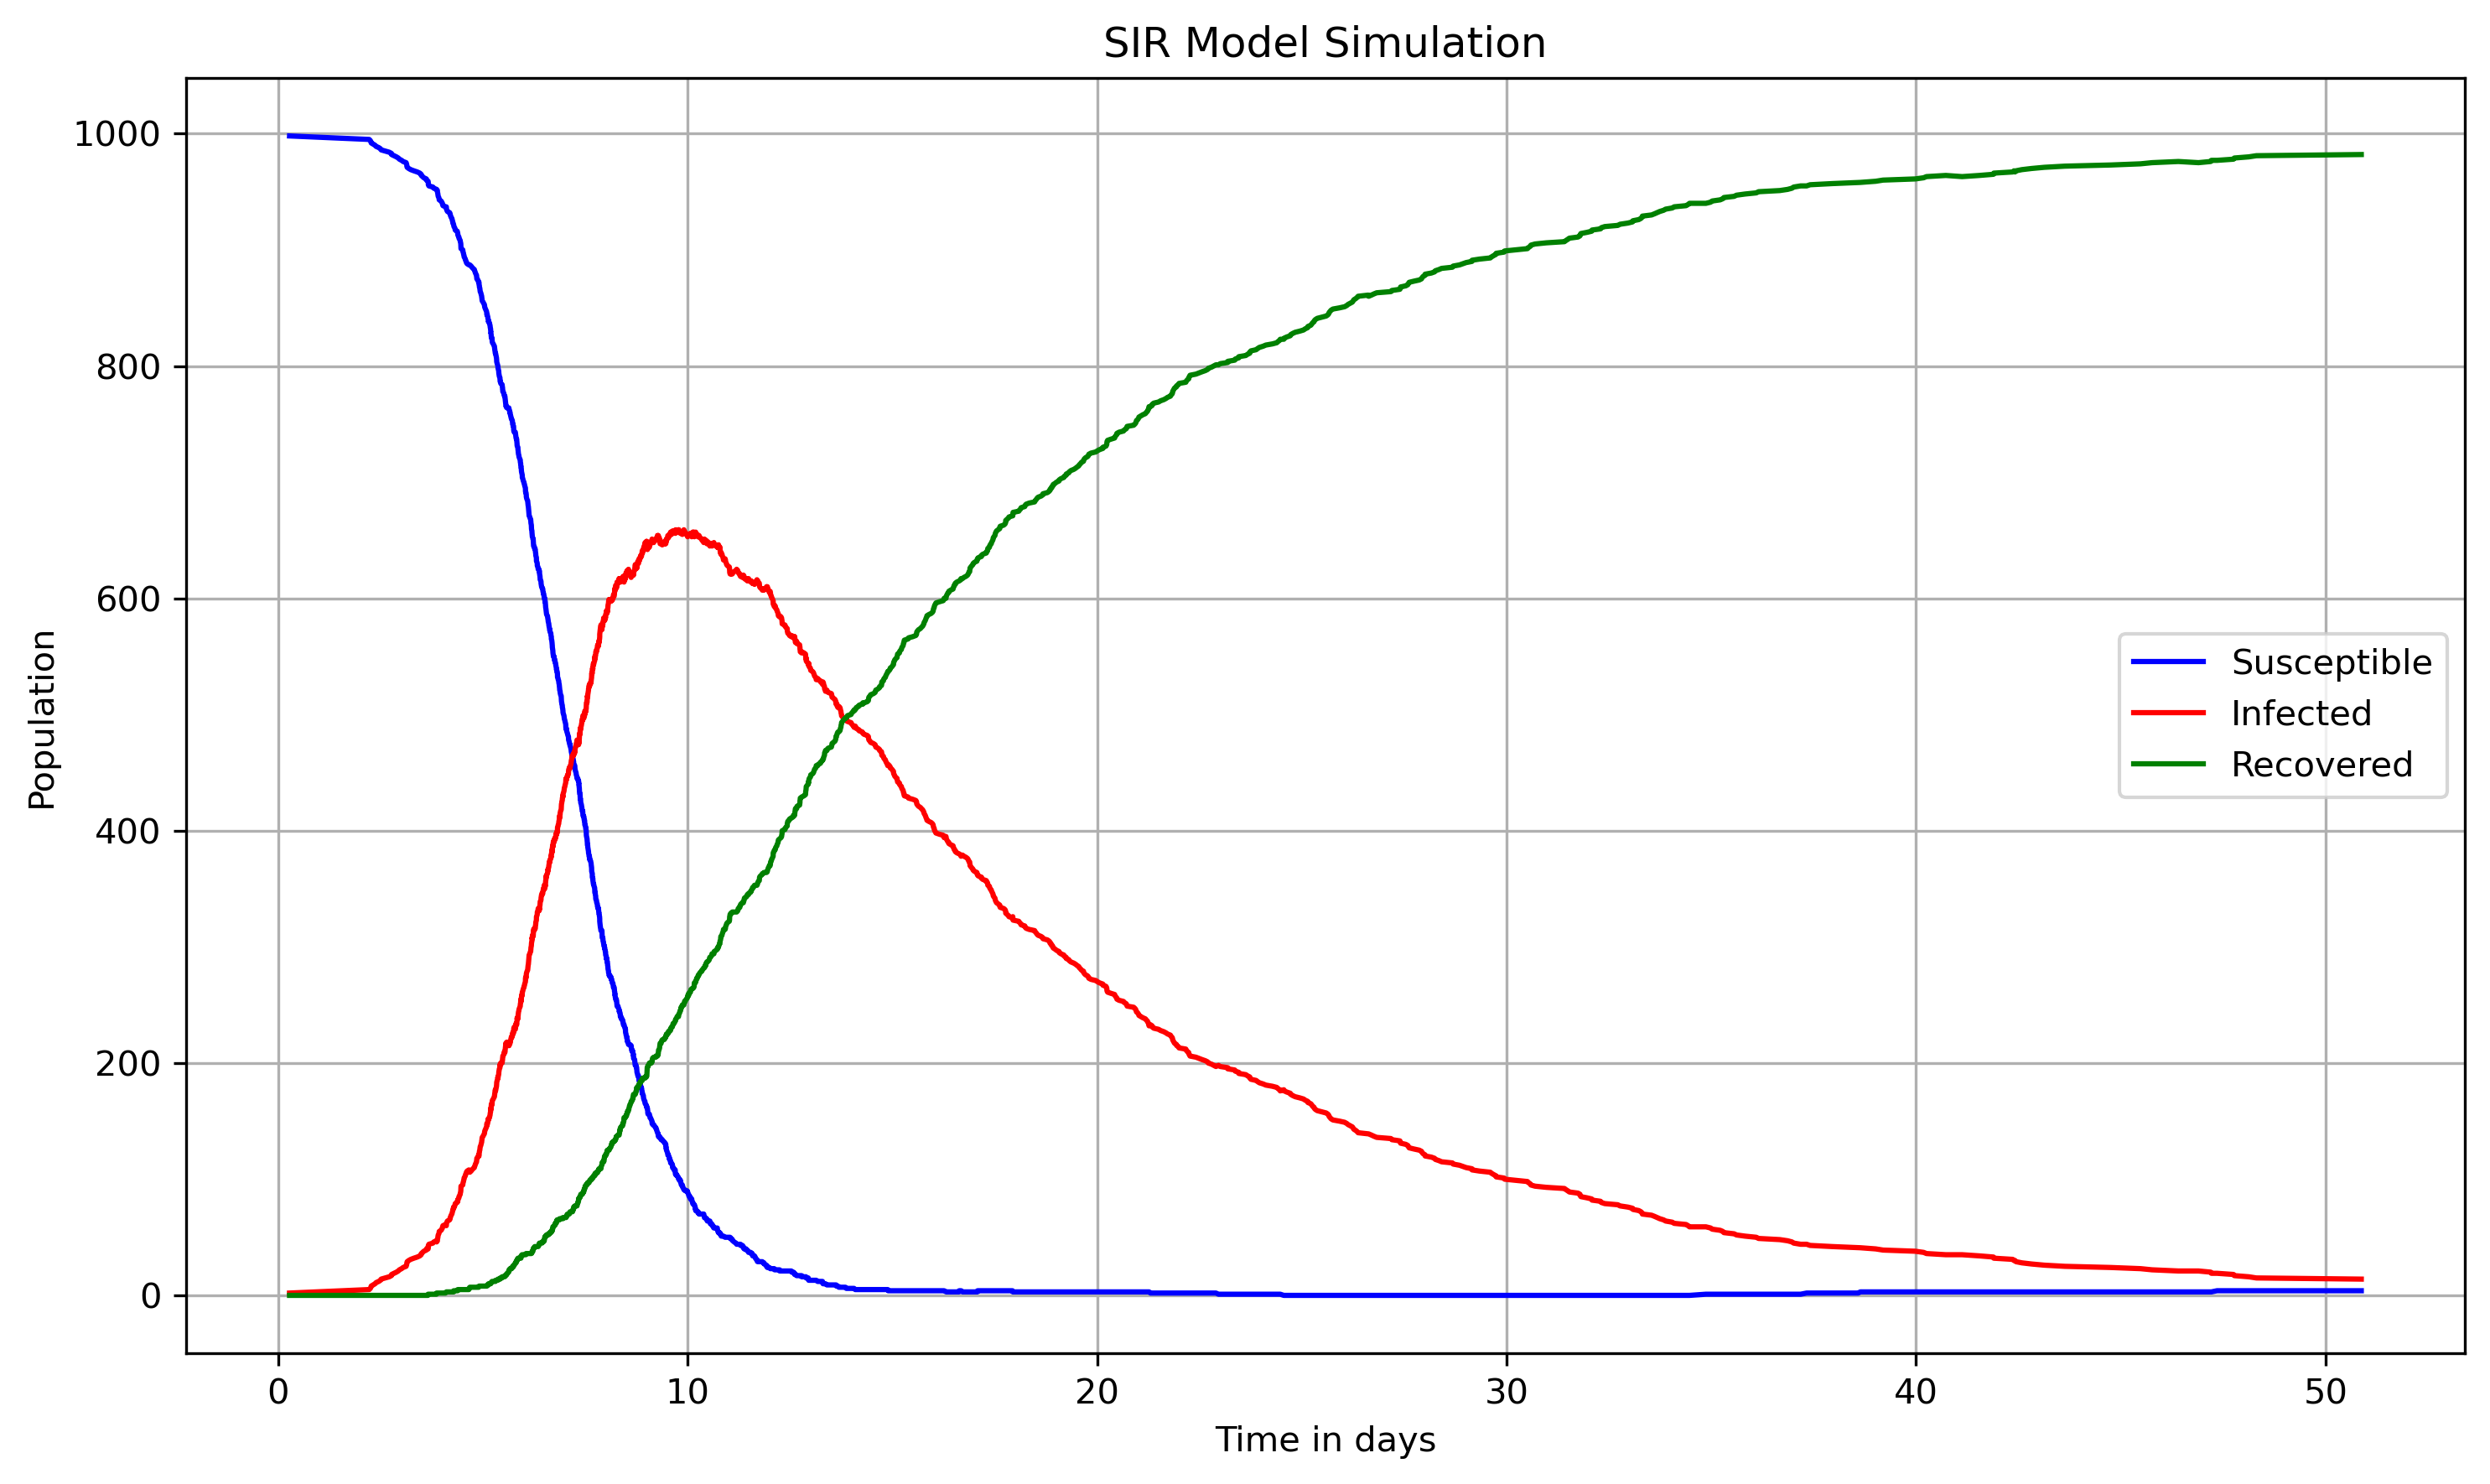

In [127]:
# TEST plot result
initialize_plot()
plot_single_result(result)
add_description_to_plot()
# save_plot('testin_single_plot')
show_plot()

In [35]:
# TEST run multiple simulations
beta = 1
gamma = 0.1
mu = 0.02/356
params = {'beta': beta, 'gamma': gamma, 'mu': mu}

N = 1e3
initial_values = {'X': N - 1, 'Y': 1, 'Z': 0}

end_time = 50
no_runs = 50

results = run_multiple_simulations(params, initial_values, end_time, no_runs)

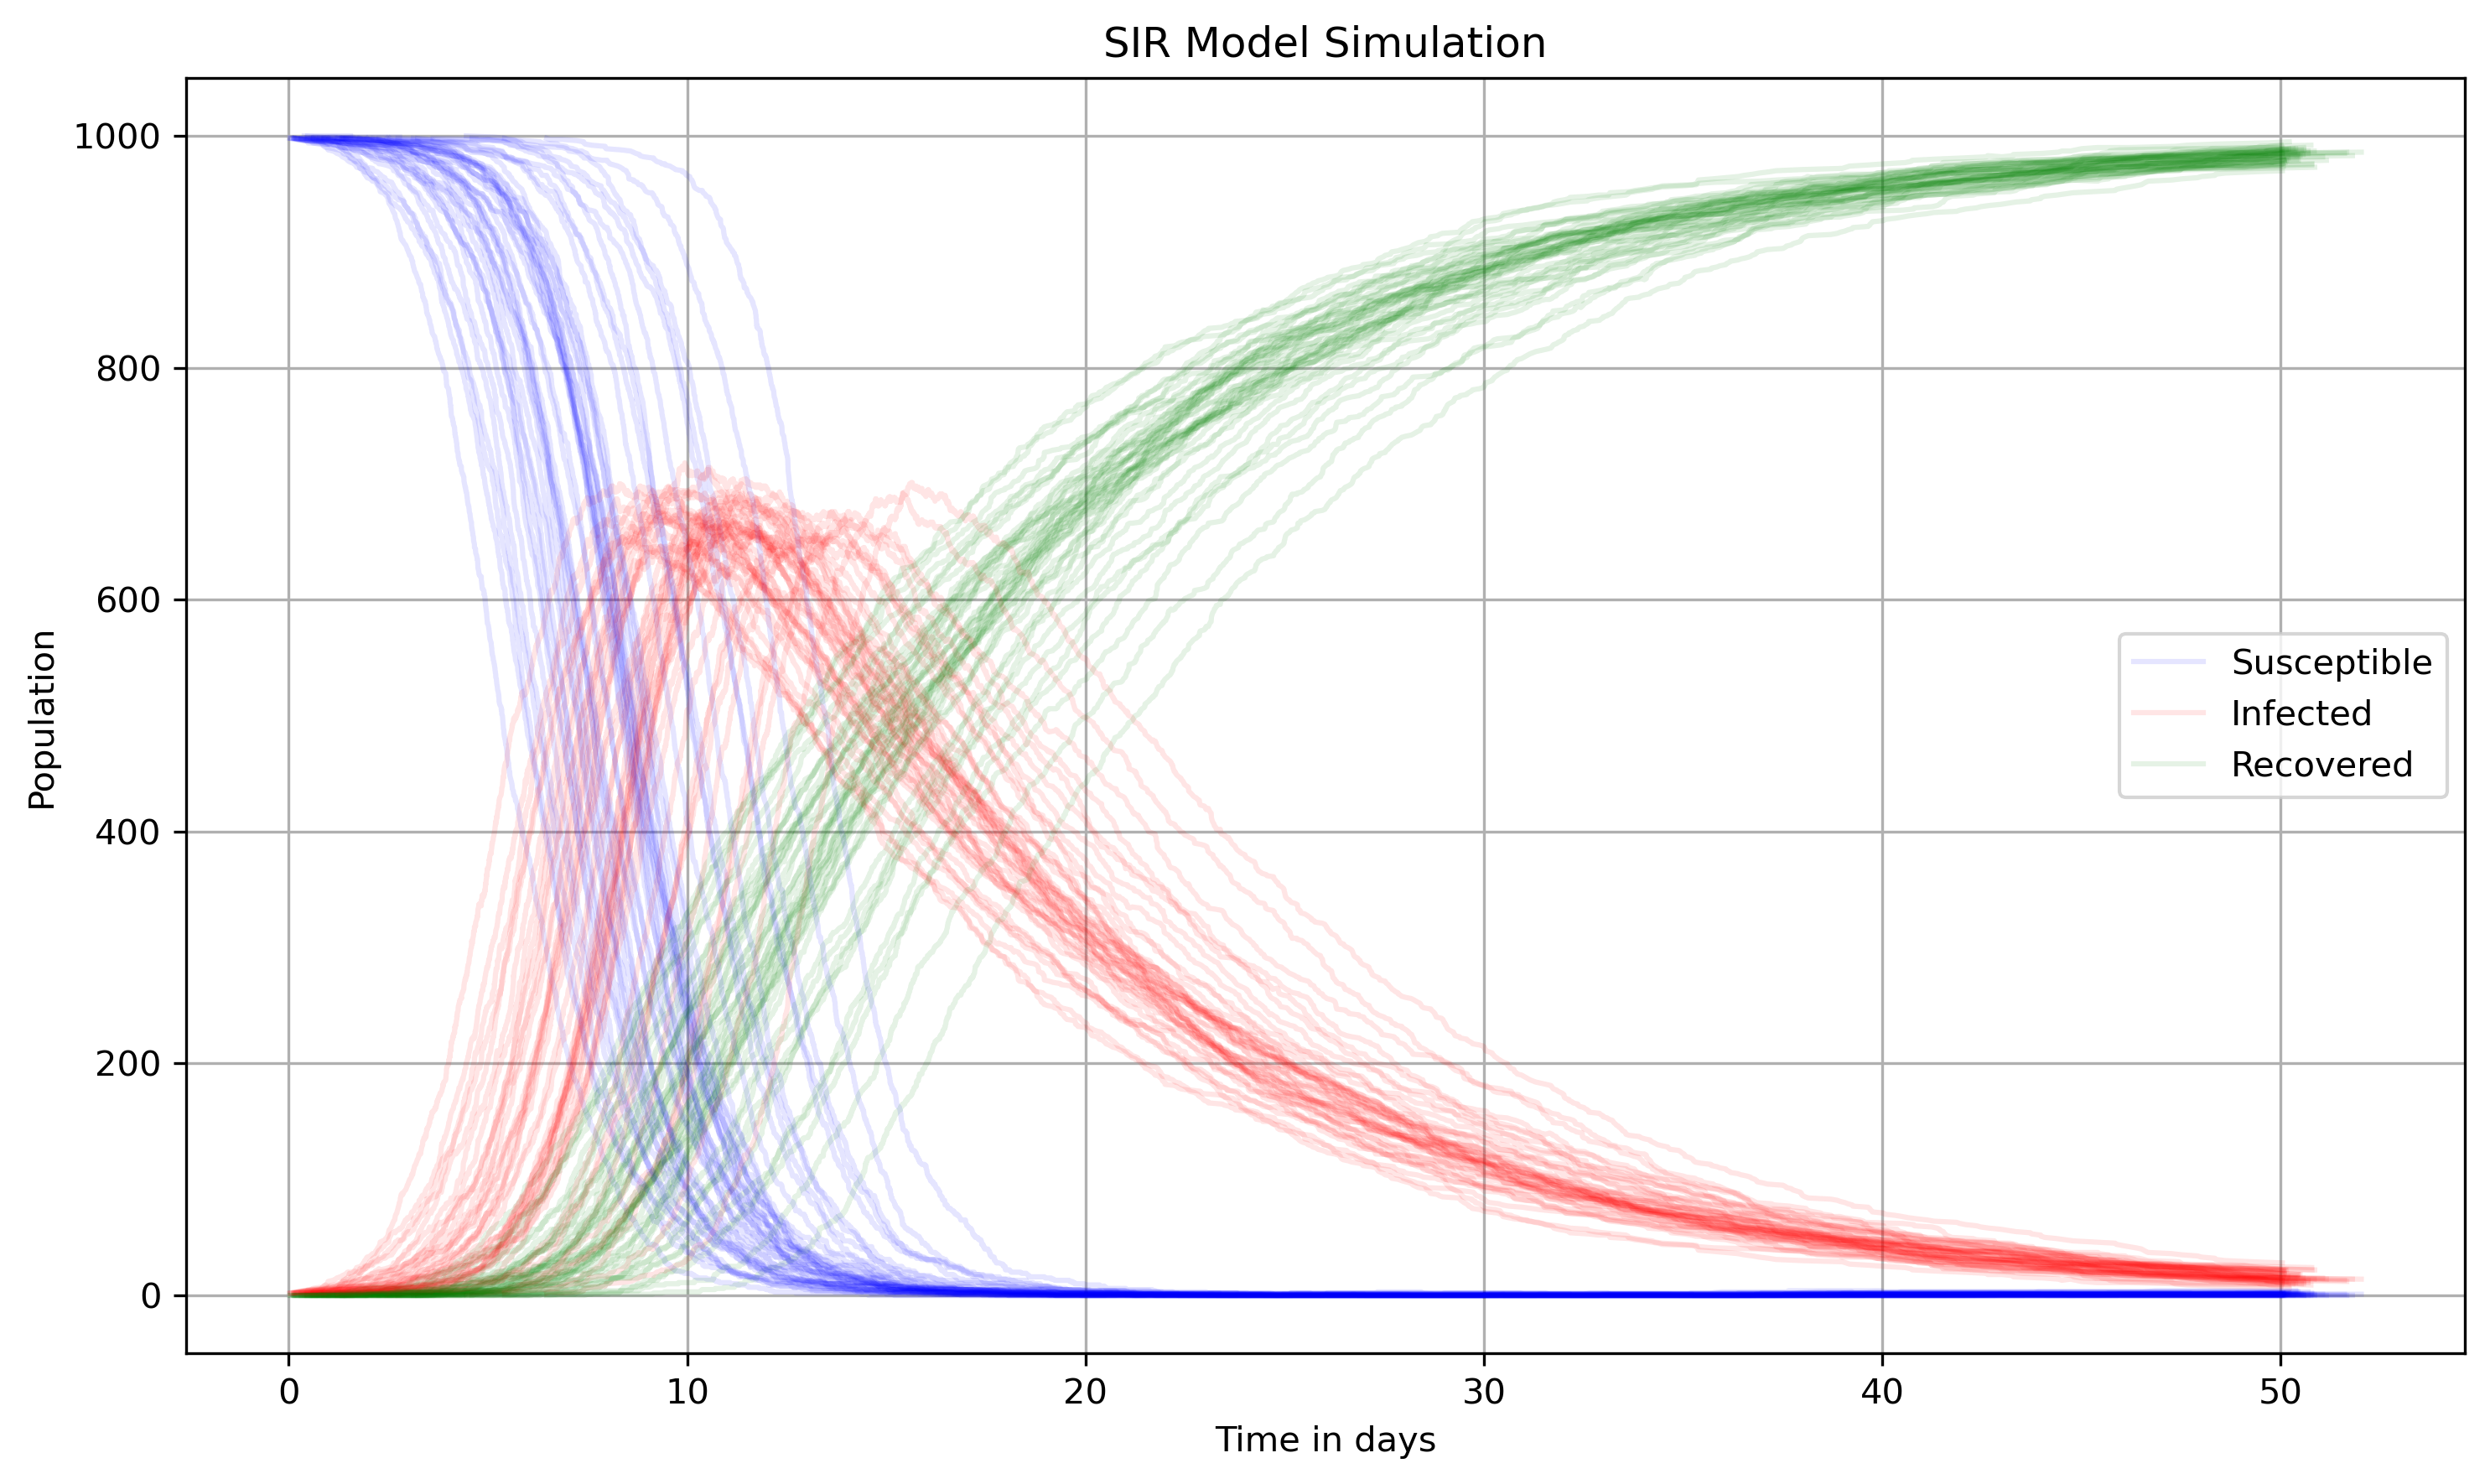

In [37]:
# TEST plot multiple simulations
initialize_plot()
plot_multiple_results(results)
add_description_to_plot_multiple_simulations()
show_plot()

### Deterministic SIR Model 

In [71]:
def SIR_deterministic(y, t, beta, gamma, mu):
    # Initialize variables
    X, Y, Z = y
    N = X + Y + Z
    # beta, gamma, mu = params['beta'], params['gamma'], params['mu']

    # Define the equations
    dXdt = - beta * X * Y / N + mu * N - mu * X
    dYdt = beta * X * Y / N - gamma * Y - mu * Y
    dZdt = gamma * Y - mu * Z
    
    return [dXdt, dYdt, dZdt]

In [107]:
def solve_SIR_deterministic(params, initial_values, end_time):
    # Prepare time points
    time_points = np.linspace(0, end_time, 100)
    initial_values_array = [initial_values['X'], initial_values['Y'], initial_values['Z']]

    # Run solver
    solution = odeint(SIR_deterministic, initial_values_array, time_points, args=(params['beta'], params['gamma'], params['mu']))

    return solution

In [145]:
# TEST solve deterministic SIR
beta = 1
gamma = 0.1
mu = 0.02/356
params = {'beta': beta, 'gamma': gamma, 'mu': mu}

N = 1e3
initial_values = {'X': N - 1, 'Y': 1, 'Z': 0}

end_time = 50

deterministic_result = solve_SIR_deterministic(params, initial_values, end_time)

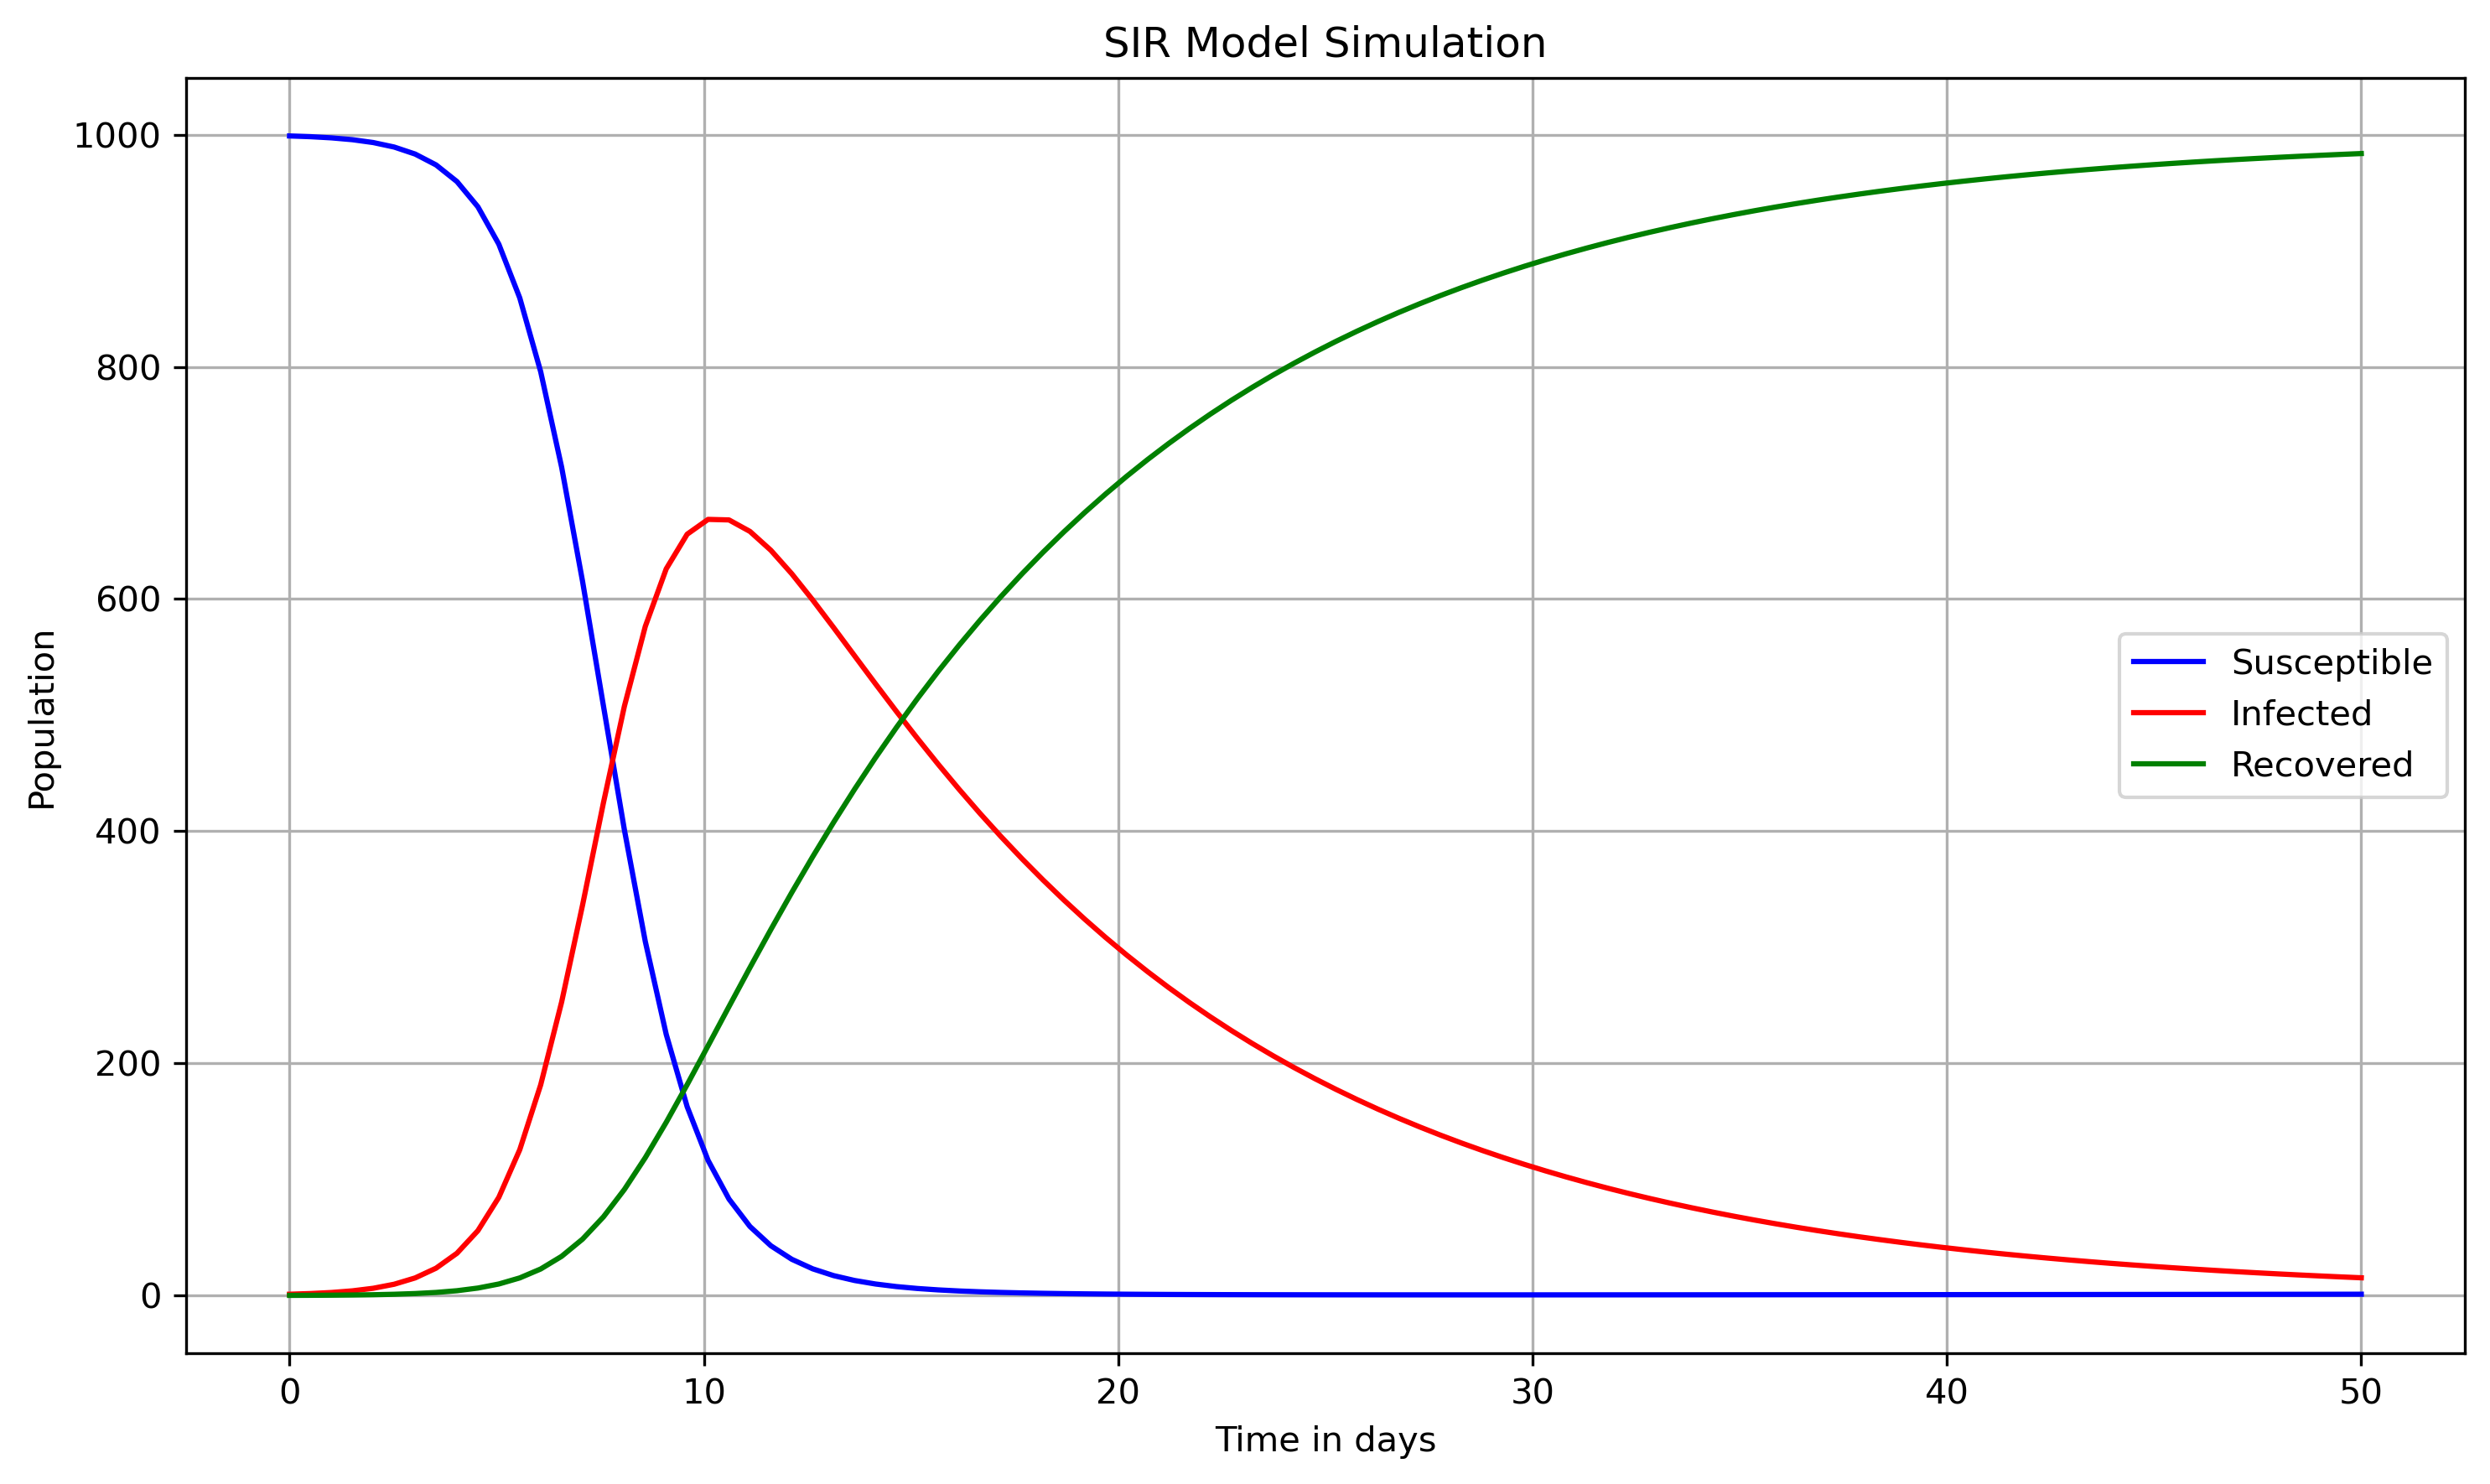

In [147]:
# TEST plot deterministic SIR
deterministic_result_dict = {'time': np.linspace(0, end_time, 100), 'X': deterministic_result[:, 0], 'Y': deterministic_result[:, 1], 'Z': deterministic_result[:, 2]}

initialize_plot()
plot_single_result(deterministic_result_dict)
add_description_to_plot()
# save_plot('testin_single_plot')
show_plot()

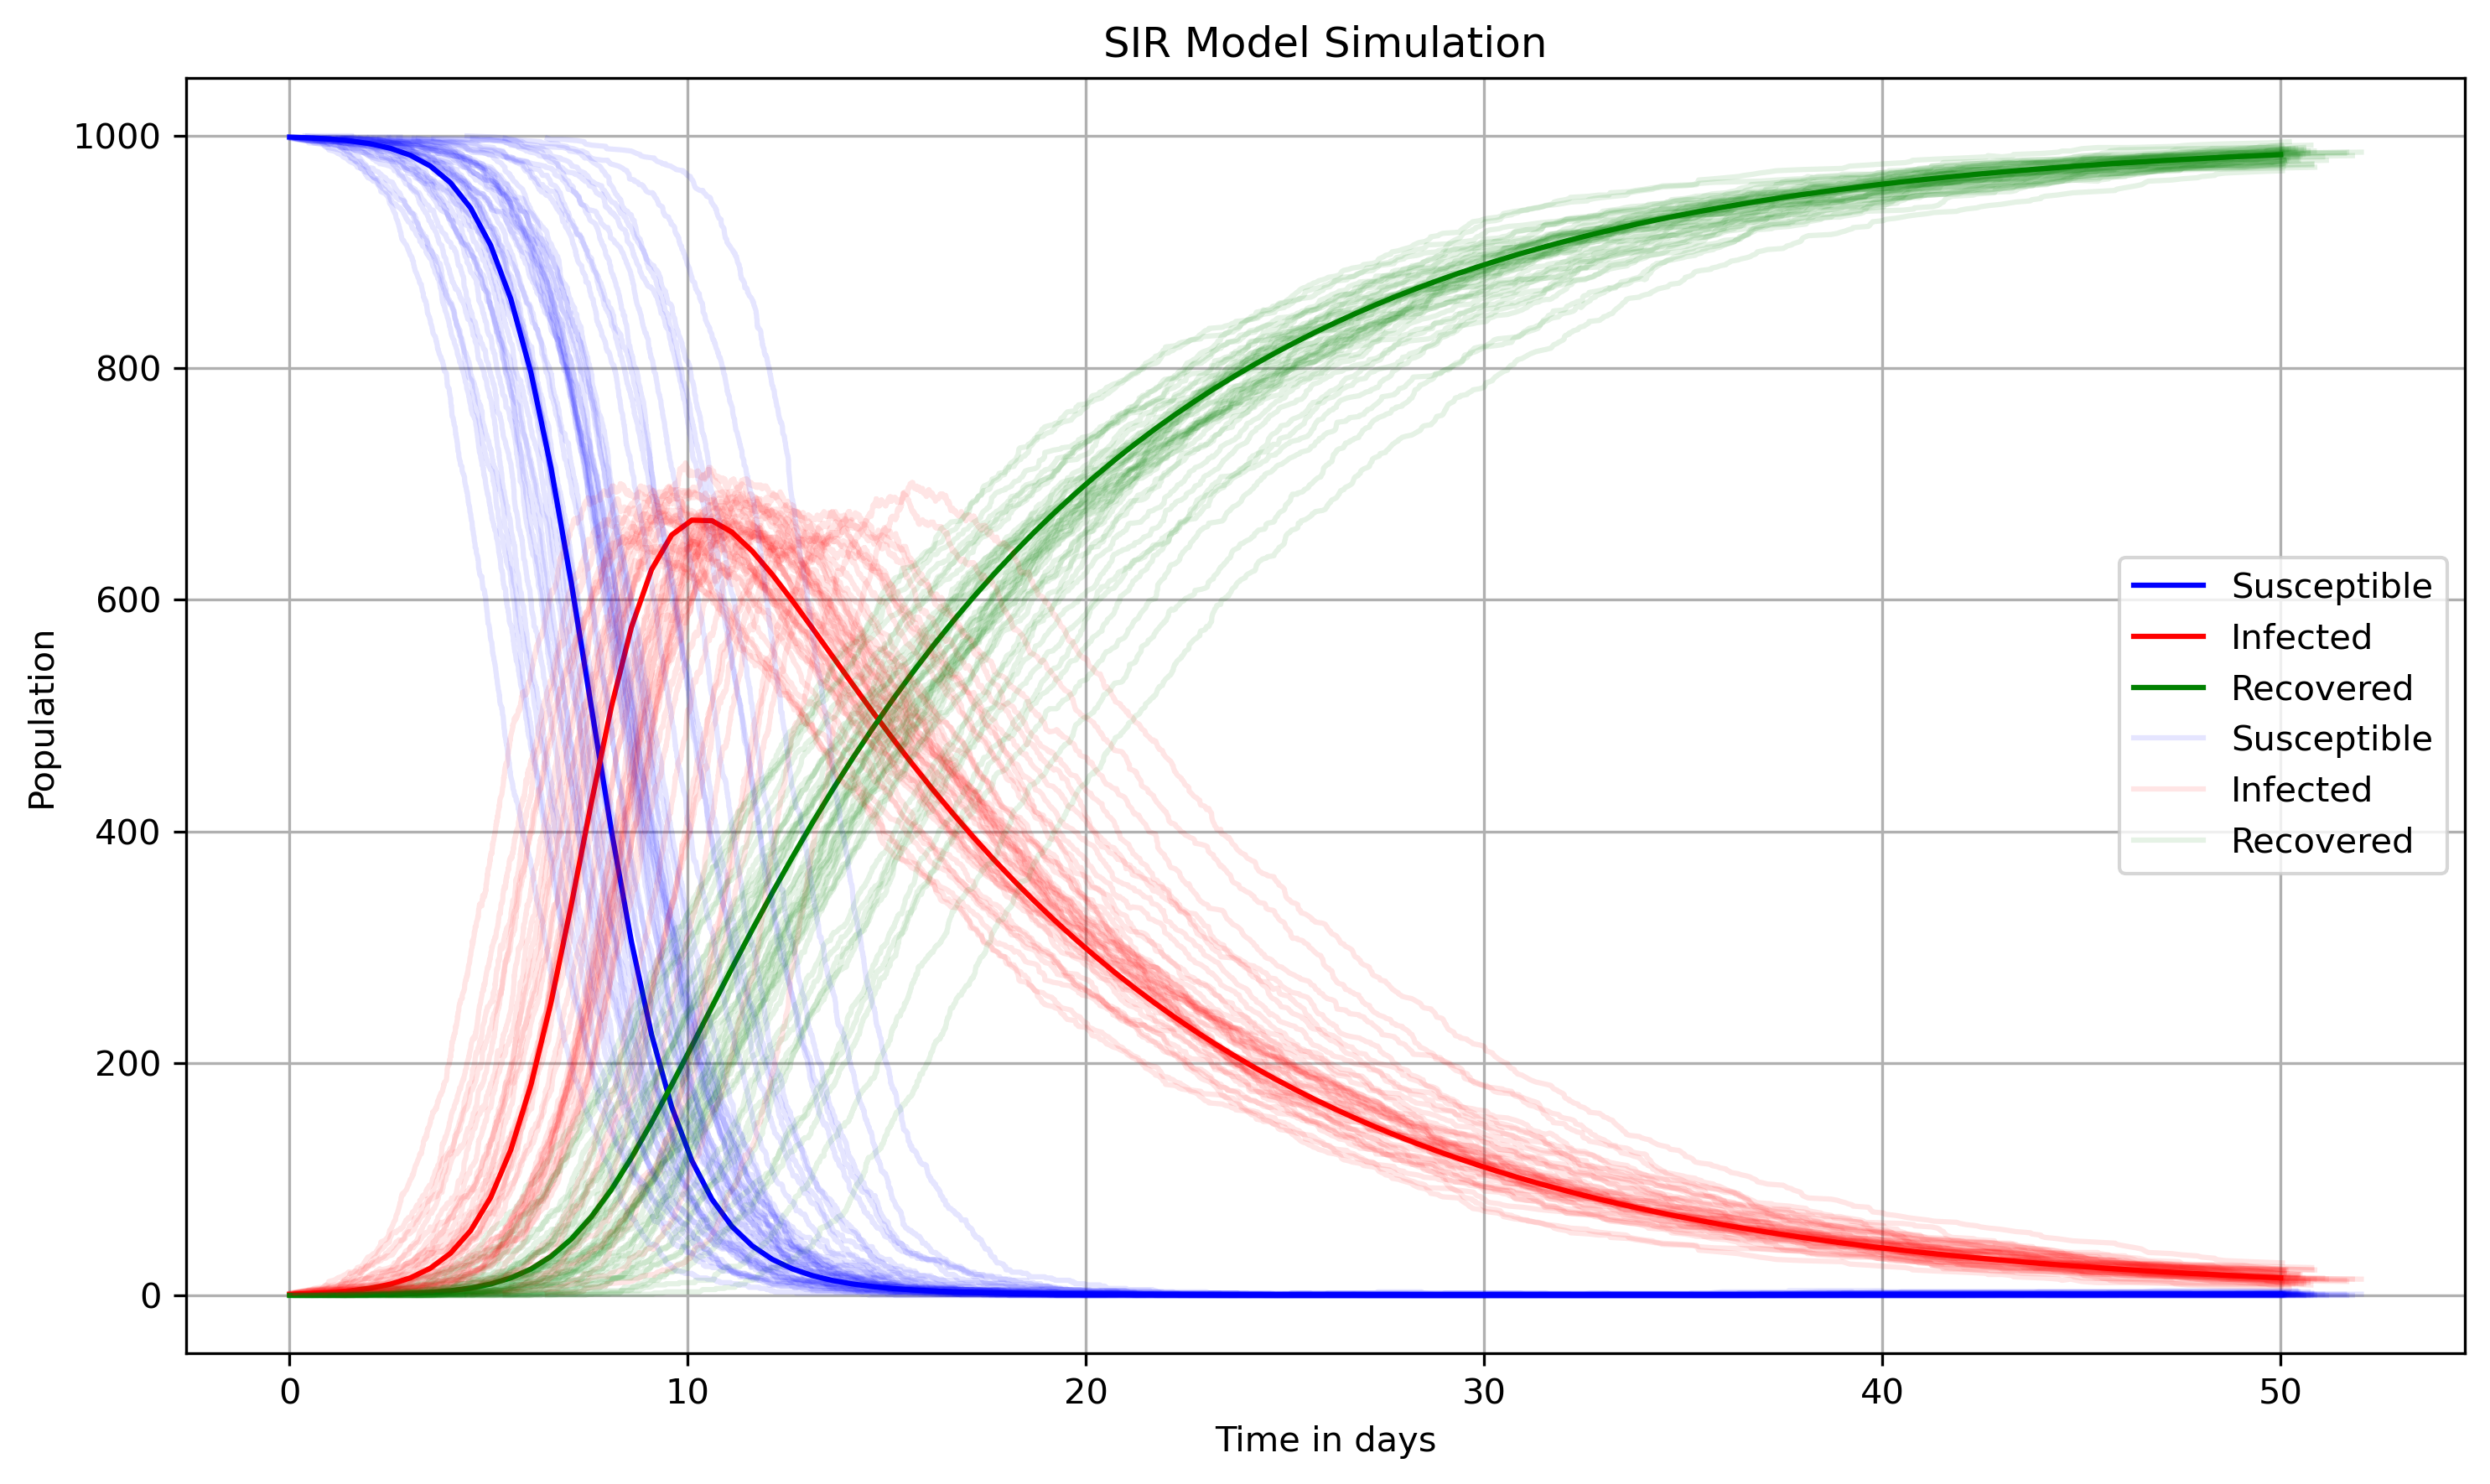

In [123]:
# TEST plot deterministic + multiple simulations
deterministic_result_dict = {'time': np.linspace(0, end_time, 100), 'X': deterministic_result[:, 0], 'Y': deterministic_result[:, 1], 'Z': deterministic_result[:, 2]}

initialize_plot()
plot_single_result(deterministic_result_dict)
plot_multiple_results(results)
add_description_to_plot()
# save_plot('testin_single_plot')
show_plot()

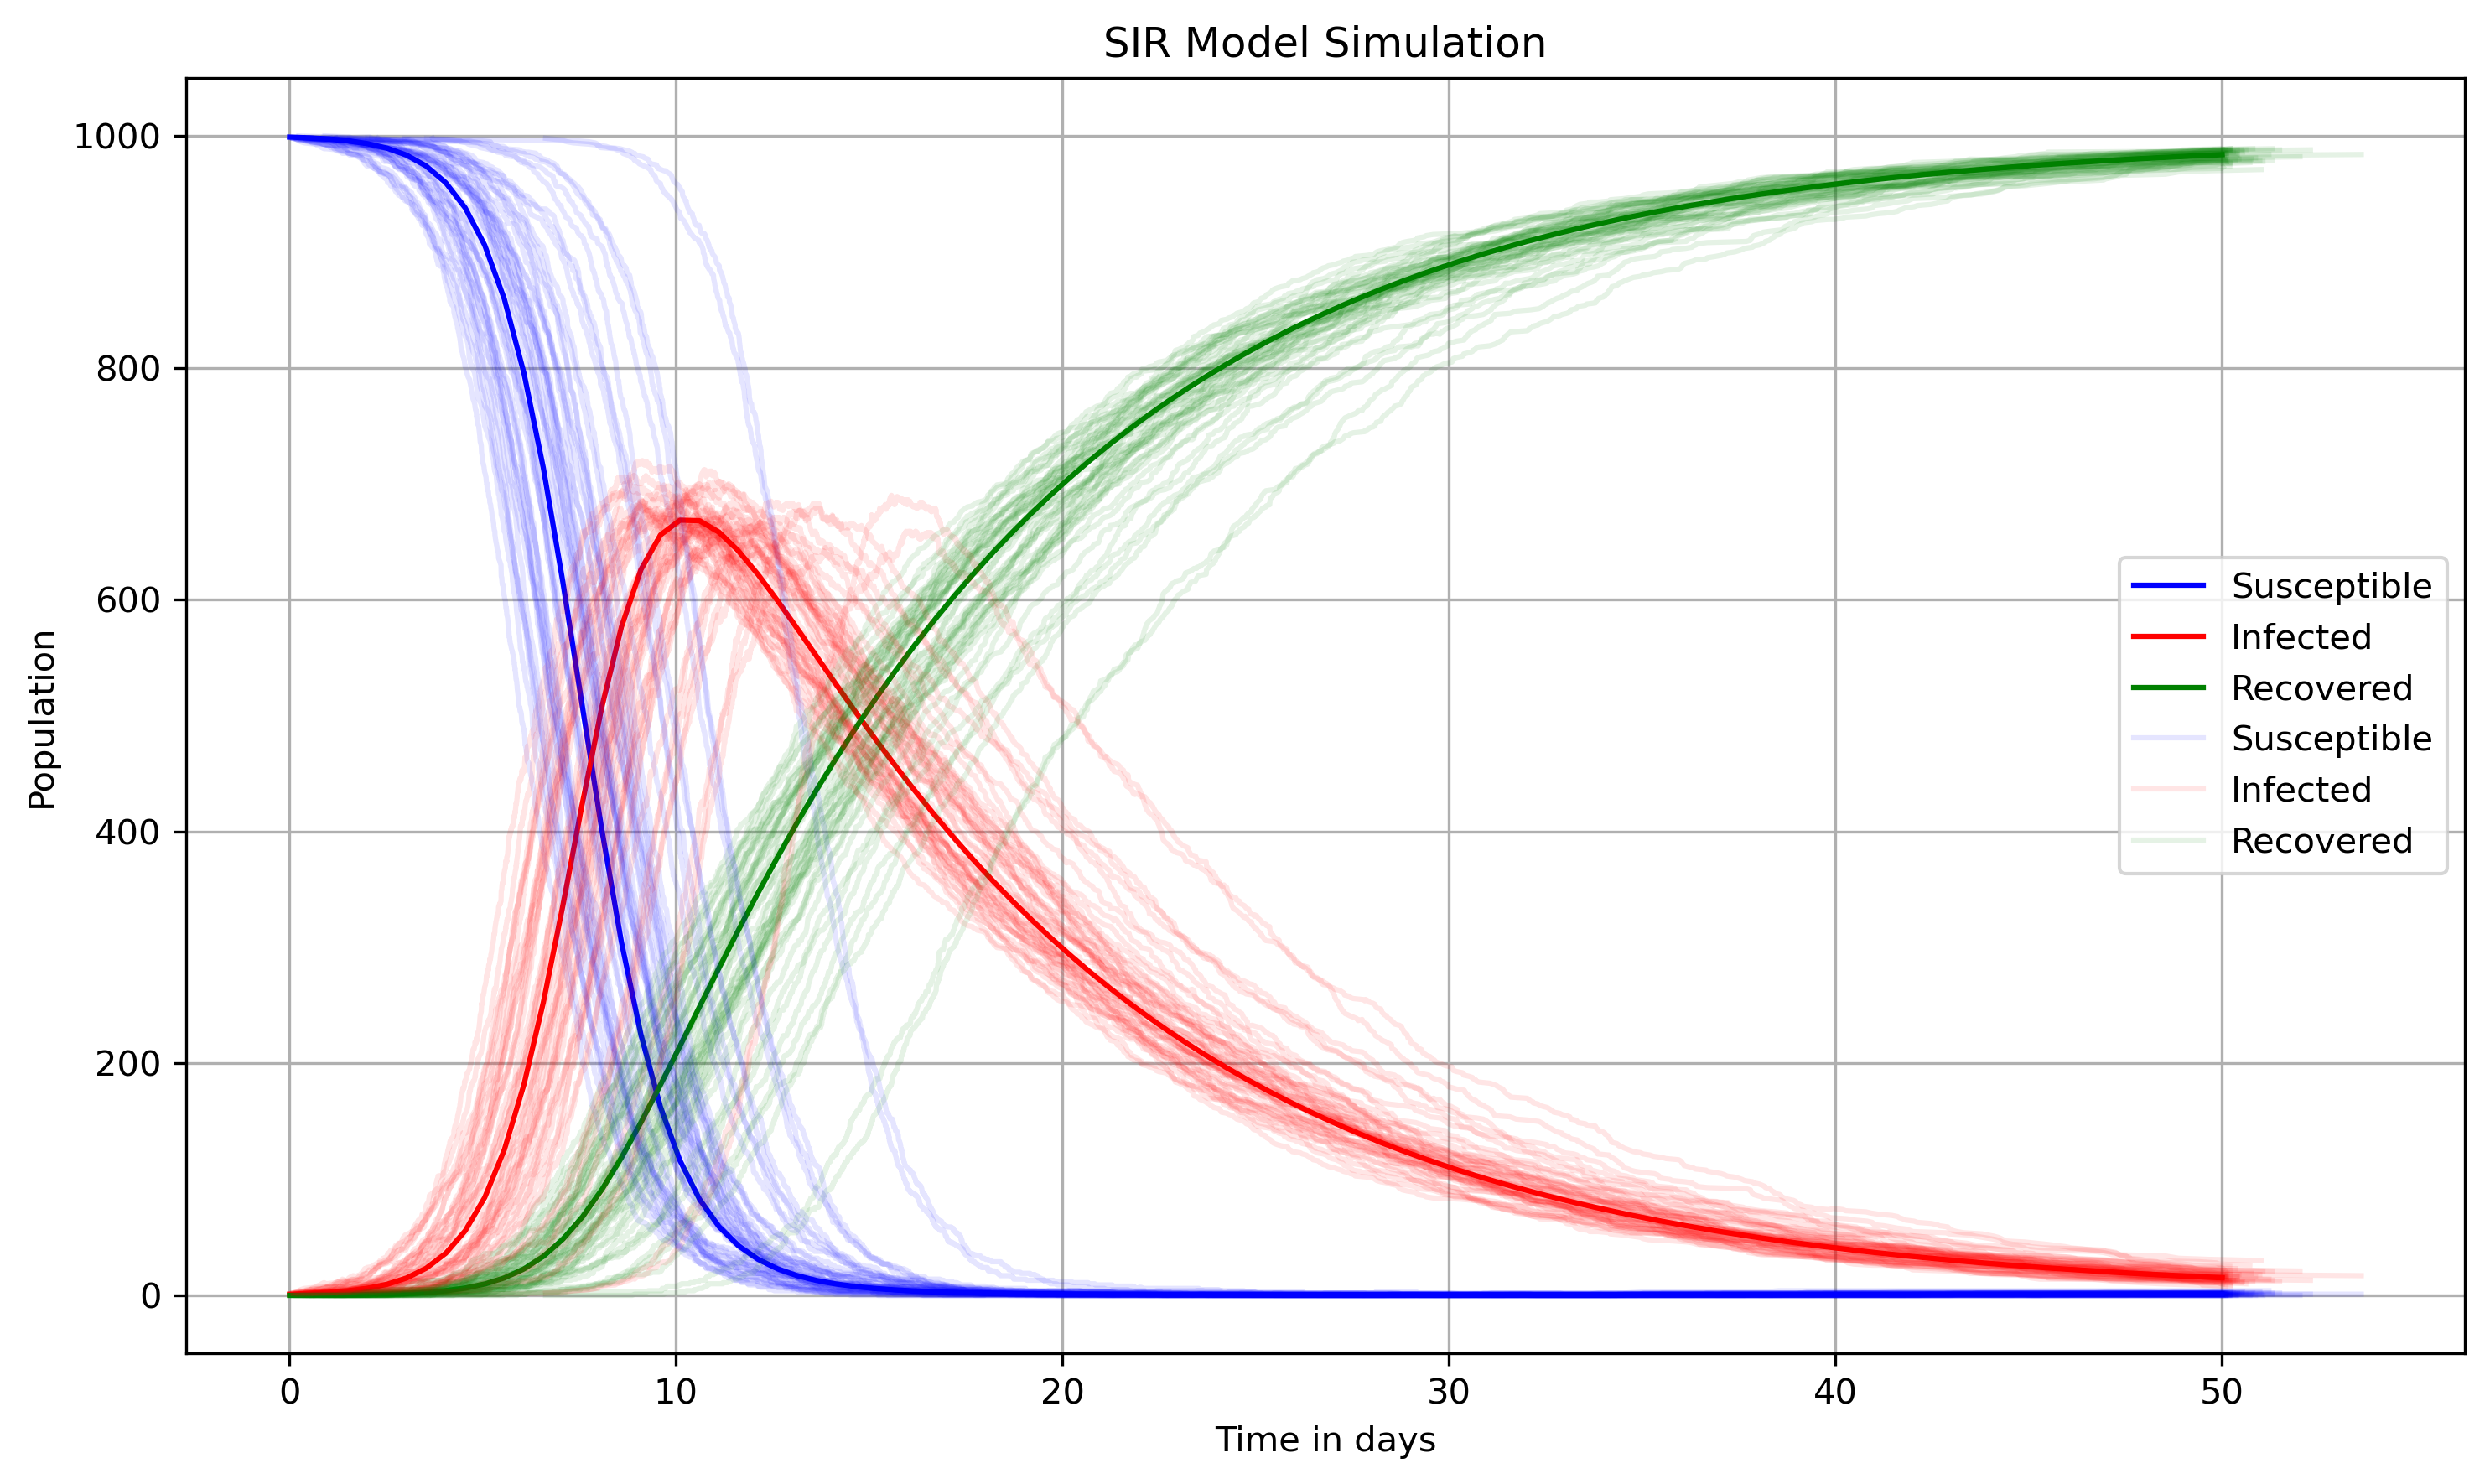

In [165]:
# TEST run multiple simulations + deterministic
beta = 1
gamma = 0.1
mu = 0.02/356
params = {'beta': beta, 'gamma': gamma, 'mu': mu}

N = 1e3
initial_values = {'X': N - 1, 'Y': 1, 'Z': 0}

end_time = 50
no_runs = 50

# Solve
results = run_multiple_simulations(params, initial_values, end_time, no_runs)
deterministic_result = solve_SIR_deterministic(params, initial_values, end_time)

# Plot
deterministic_result_dict = {'time': np.linspace(0, end_time, 100), 'X': deterministic_result[:, 0], 'Y': deterministic_result[:, 1], 'Z': deterministic_result[:, 2]}

initialize_plot()
plot_single_result(deterministic_result_dict)
plot_multiple_results(results)
add_description_to_plot()
show_plot()